# Percobaan 1 (Raw / Tanpa Preprocessing) — Klasifikasi Roti Tawar Berjamur

**Catatan:** Notebook ini sama seperti Percobaan1.ipynb, tapi tahap Preprocessing (Grayscale + Histogram Equalization + Normalisasi) di-skip. Data yang dipakai untuk ekstraksi fitur GLCM adalah citra **grayscale biasa** (cv.cvtColor saja, tanpa Histogram Equalization & tanpa normalisasi manual) — supaya kelihatan bagaimana hasil data asli sebelum preprocessing.

## 1. Import Library

In [1]:
import os, warnings
import cv2 as cv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                              precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay)
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy as sp_entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
warnings.filterwarnings('ignore')
print("Library berhasil diimport!")

Library berhasil diimport!


## 2. Load Data

Struktur folder:
```
dataset/
├── fresh_bread/
│   └── *.jpg
└── spoiled_bread/
    └── *.jpg
```

In [2]:
data       = []
labels     = []
file_name  = []

TARGET_SIZE  = (128, 128)
dataset_path = "dataset"

for sub_folder in sorted(os.listdir(dataset_path)):
    sub_path = os.path.join(dataset_path, sub_folder)
    if not os.path.isdir(sub_path):
        continue
    for filename in os.listdir(sub_path):
        if not filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        img = cv.imread(os.path.join(sub_path, filename))
        if img is None:
            continue
        img = cv.resize(img, TARGET_SIZE).astype(np.uint8)
        data.append(img)
        labels.append(sub_folder)
        file_name.append(filename)

data   = np.array(data)
labels = np.array(labels)
print(f"Total gambar dimuat : {len(data)}")
print(f"Shape tiap gambar   : {data[0].shape}  → (H x W x 3, format BGR)")
print(f"Distribusi kelas    : {dict(zip(*np.unique(labels, return_counts=True)))}")

Total gambar dimuat : 200
Shape tiap gambar   : (128, 128, 3)  → (H x W x 3, format BGR)
Distribusi kelas    : {np.str_('fresh_bread'): np.int64(100), np.str_('spoiled_bread'): np.int64(100)}


## 3. Data Understanding

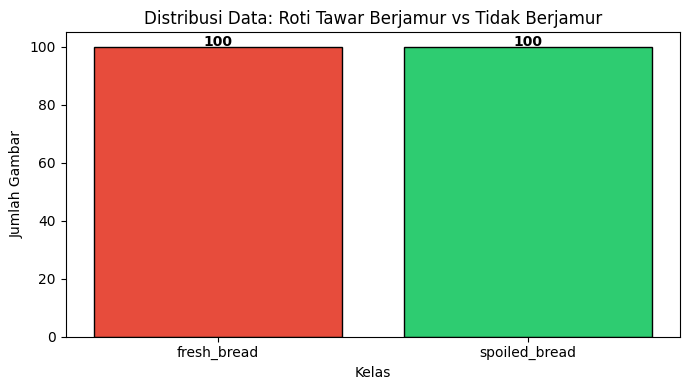

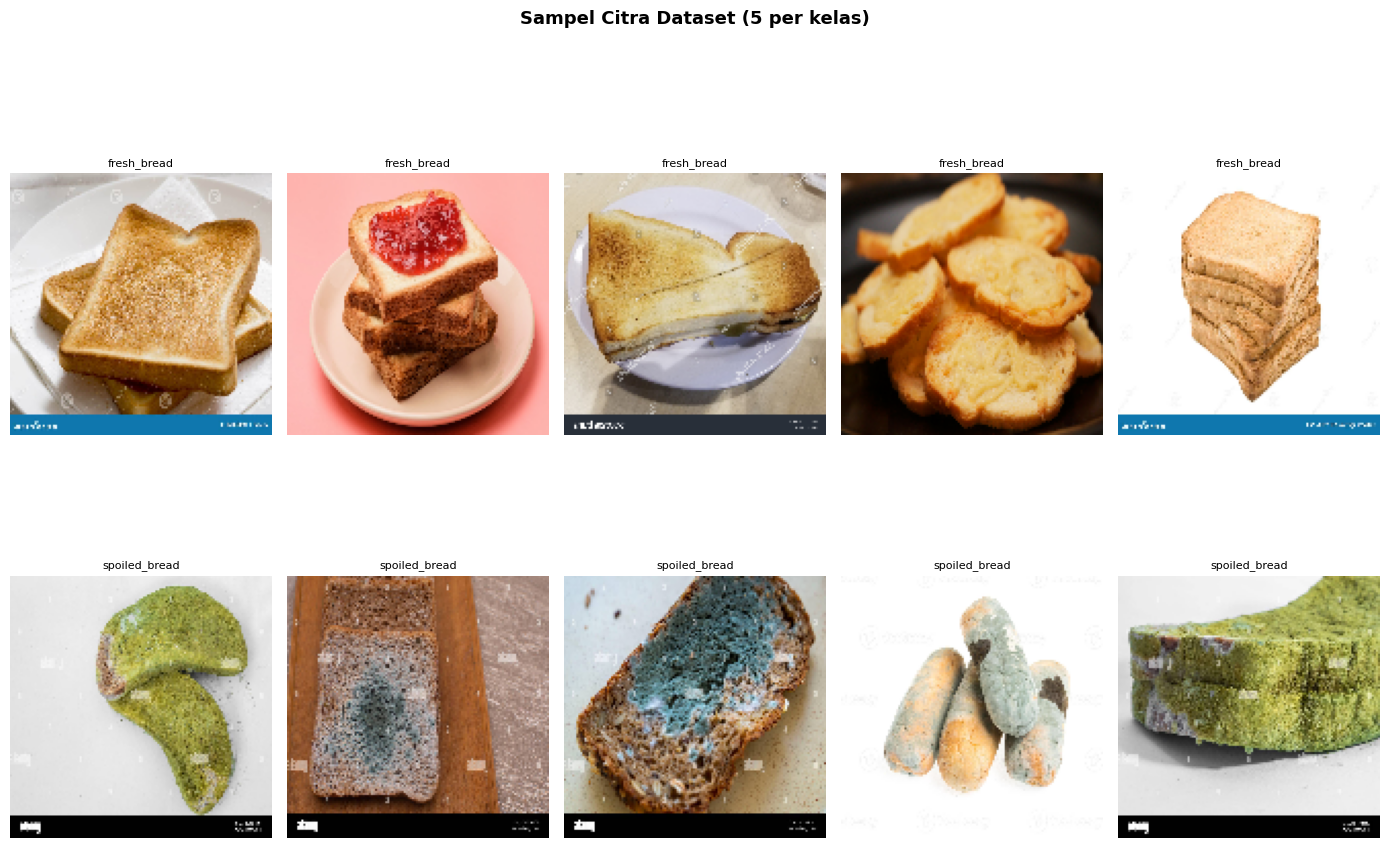

In [3]:
unique, counts = np.unique(labels, return_counts=True)

# Bar chart distribusi
plt.figure(figsize=(7, 4))
bars = plt.bar(unique, counts, color=['#e74c3c','#2ecc71'], edgecolor='black')
for b, c in zip(bars, counts):
    plt.text(b.get_x() + b.get_width()/2, b.get_height()+0.3, str(c), ha='center', fontweight='bold')
plt.title('Distribusi Data: Roti Tawar Berjamur vs Tidak Berjamur')
plt.xlabel('Kelas'); plt.ylabel('Jumlah Gambar')
plt.tight_layout(); plt.show()

# Sampel 5 gambar per kelas
fig, axes = plt.subplots(len(unique), 5, figsize=(14, 5*len(unique)))
fig.suptitle('Sampel Citra Dataset (5 per kelas)', fontsize=13, fontweight='bold')
for r, kelas in enumerate(unique):
    idxs = np.where(labels == kelas)[0][:5]
    row_axes = axes[r] if len(unique) > 1 else axes
    for c, idx in enumerate(idxs):
        row_axes[c].imshow(cv.cvtColor(data[idx], cv.COLOR_BGR2RGB))
        row_axes[c].set_title(kelas, fontsize=8); row_axes[c].axis('off')
plt.tight_layout(); plt.show()

## 4. Data Augmentation

Augmentasi aktif otomatis jika data < 70 per kelas.

In [4]:
MIN_SAMPLES = 70
unique_cls, counts_cls = np.unique(labels, return_counts=True)
needs_aug = any(c < MIN_SAMPLES for c in counts_cls)

data_aug      = list(data.copy())
labels_aug    = list(labels.copy())
file_name_aug = list(file_name.copy())

if needs_aug:
    print("Data < batas minimum → menjalankan augmentasi...")
    for i in range(len(data)):
        img, lbl, fn = data[i], labels[i], file_name[i]
        data_aug.append(cv.flip(img, 1));        labels_aug.append(lbl); file_name_aug.append("aug_flipH_" + fn)
        data_aug.append(cv.flip(img, 0));        labels_aug.append(lbl); file_name_aug.append("aug_flipV_" + fn)
        data_aug.append(cv.rotate(img, cv.ROTATE_90_CLOCKWISE)); labels_aug.append(lbl); file_name_aug.append("aug_rot90_" + fn)
    print(f"Sebelum augmentasi : {len(data)}")
    print(f"Setelah augmentasi : {len(data_aug)}")
else:
    print("Data sudah mencukupi, augmentasi dilewati.")
    print(f"Total gambar       : {len(data_aug)}")

data_aug      = np.array(data_aug)
labels_aug    = np.array(labels_aug)
file_name_aug = np.array(file_name_aug)
print(f"Distribusi kelas   : {dict(zip(*np.unique(labels_aug, return_counts=True)))}")

Data sudah mencukupi, augmentasi dilewati.
Total gambar       : 200
Distribusi kelas   : {np.str_('fresh_bread'): np.int64(100), np.str_('spoiled_bread'): np.int64(100)}


## 5. (Tanpa Preprocessing) — Konversi Grayscale Saja

Tidak ada Histogram Equalization & tidak ada normalisasi manual. Hanya grayscale biasa, supaya bisa lihat data "asli".

In [ ]:
# ═══════════════════════════════════════════════════
# TANPA PREPROCESSING: hanya Grayscale biasa (tidak ada HE & normalisasi)
# ═══════════════════════════════════════════════════

def raw_gray(image):
    """
    Tanpa preprocessing tambahan.
    - Grayscale saja (cv.cvtColor) supaya bisa dipakai untuk GLCM (butuh 1 channel).
    - TIDAK ada Histogram Equalization.
    - TIDAK ada normalisasi manual.
    """
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY) if image.ndim == 3 else image.copy()
    return gray.astype(np.uint8)


# ── Preview: Original vs Grayscale biasa (TANPA HE & Normalisasi) ──
fig, axes = plt.subplots(len(np.unique(labels)), 2, figsize=(8, 5*len(np.unique(labels))))
fig.suptitle('Tanpa Preprocessing: Original vs Grayscale (saja)', fontsize=12, fontweight='bold')
for r, kelas in enumerate(np.unique(labels)):
    idx  = np.where(labels == kelas)[0][0]
    img  = data[idx]
    gray = raw_gray(img)
    row  = axes[r] if len(np.unique(labels)) > 1 else axes
    row[0].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB)); row[0].set_title(f'Original ({kelas})'); row[0].axis('off')
    row[1].imshow(gray, cmap='gray');                  row[1].set_title('Grayscale (tanpa HE & Normalisasi)'); row[1].axis('off')
plt.tight_layout(); plt.show()

### Terapkan (Tanpa Preprocessing) ke Seluruh Dataset

In [ ]:
# Percobaan 1 (Raw): tanpa preprocessing, hanya grayscale
dataP1 = [raw_gray(img) for img in data_aug]

# list_prepro dipakai untuk visualisasi semua gambar
list_prepro = [[dataP1[i]] for i in range(len(data_aug))]

dataPreprocessed = np.array(dataP1)
print(f" Total diproses: {len(dataPreprocessed)} gambar (tanpa HE & normalisasi)")

### Visualisasi Hasil (Tanpa Preprocessing) Semua Gambar

In [ ]:
# Tampilkan SEMUA gambar hasil preprocessing (1 baris = 1 gambar)
col_titles = ['Original', 'Grayscale (Tanpa Preprocessing)']
n_cols     = 2

fig, axes = plt.subplots(len(data_aug), n_cols, figsize=(n_cols * 4, len(data_aug) * 3))
fig.suptitle('Hasil (Tanpa Preprocessing) Semua Gambar — Percobaan 1', fontsize=13, fontweight='bold')

for i in range(len(data_aug)):
    # Kolom 0: Original
    axes[i, 0].imshow(cv.cvtColor(data_aug[i], cv.COLOR_BGR2RGB))
    axes[i, 0].set_title(f'Original\n{labels_aug[i]}', fontsize=7)
    axes[i, 0].axis('off')
    # Kolom berikutnya: hasil preprocessing
    for j, img_pre in enumerate(list_prepro[i]):
        axes[i, j+1].imshow(img_pre, cmap='gray')
        axes[i, j+1].set_title(col_titles[j+1], fontsize=7)
        axes[i, j+1].axis('off')

plt.tight_layout()
plt.show()
print(f"Total gambar ditampilkan: {len(data_aug)}")

## 6. Feature Extraction (GLCM)

Sudut 0°/45°/90°/135°, simetris, distance 1–5.

In [ ]:
def extract_glcm_features(image_uint8, distances=[1,2,3,4,5]):
    angles    = [0, np.pi/4, np.pi/2, 3*np.pi/4]
    ang_names = ['0','45','90','135']
    features  = {}
    for d in distances:
        mat = graycomatrix(image_uint8, distances=[d], angles=angles,
                           levels=256, symmetric=True, normed=True)
        for ai, an in enumerate(ang_names):
            g = mat[:, :, 0:1, ai:ai+1]
            features[f'Contrast_d{d}_a{an}']     = graycoprops(g, 'contrast')[0,0]
            features[f'Dissimilarity_d{d}_a{an}'] = graycoprops(g, 'dissimilarity')[0,0]
            features[f'Homogeneity_d{d}_a{an}']   = graycoprops(g, 'homogeneity')[0,0]
            features[f'Energy_d{d}_a{an}']         = graycoprops(g, 'energy')[0,0]
            features[f'Correlation_d{d}_a{an}']   = graycoprops(g, 'correlation')[0,0]
            features[f'ASM_d{d}_a{an}']            = graycoprops(g, 'ASM')[0,0]
            features[f'Entropy_d{d}_a{an}']        = sp_entropy(mat[:,:,0,ai].ravel())
    return features

print("Fungsi GLCM siap!")

✓ Fungsi GLCM siap!


In [ ]:
print("Memulai ekstraksi fitur GLCM...")
print(f"Total gambar yang akan diproses: {len(dataPreprocessed)}")

all_features = []
for i, img in enumerate(dataPreprocessed):
    feats = extract_glcm_features(img, distances=[1,2,3,4,5])
    feats['Filename'] = file_name_aug[i]
    feats['Label']    = labels_aug[i]
    all_features.append(feats)
    if (i+1) % 20 == 0 or (i+1) == len(dataPreprocessed):
        print(f"  Diproses: {i+1}/{len(dataPreprocessed)}")

df = pd.DataFrame(all_features)
df.to_csv('hasil_ekstraksi_percobaan1_raw.csv', index=False)
hasilEkstrak = pd.read_csv('hasil_ekstraksi_percobaan1_raw.csv')
print(f"\n✓ Ekstraksi selesai! Shape: {hasilEkstrak.shape}")
hasilEkstrak.head()

## 7. Feature Selection (Correlation-based, threshold=0.95)

In [ ]:
hasilEkstrak = pd.read_csv('hasil_ekstraksi_percobaan1_raw.csv')
print(f"Shape data: {hasilEkstrak.shape}")

threshold = 0.95
corr_mat  = hasilEkstrak.drop(columns=['Label','Filename']).corr()
mask = np.full(corr_mat.shape[0], True, dtype=bool)
for i in range(corr_mat.shape[0]):
    for j in range(i+1, corr_mat.shape[0]):
        if abs(corr_mat.iloc[i,j]) >= threshold and mask[j]:
            mask[j] = False

selected = hasilEkstrak.drop(columns=['Label','Filename']).columns[mask]
x_new    = hasilEkstrak[selected]
y        = hasilEkstrak['Label']
print(f"Fitur sebelum seleksi : {hasilEkstrak.shape[1]-2}")
print(f"Fitur setelah seleksi : {x_new.shape[1]}")

sample_cols = list(selected[:20])
plt.figure(figsize=(16, 12))
sns.heatmap(x_new[sample_cols].corr(), annot=True, cmap='Blues', fmt=".2f", annot_kws={"size":6})
plt.title('Heatmap Korelasi Fitur Terpilih (20 pertama)')
plt.tight_layout(); plt.show()

## 8. Splitting Data (80:20) & Normalisasi (Z-score)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    x_new, y, test_size=0.2, random_state=42, stratify=y
)
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Distribusi y_train: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Distribusi y_test : {dict(zip(*np.unique(y_test, return_counts=True)))}")

X_train_mean = X_train.mean()
X_train_std  = X_train.std()
X_train_norm = (X_train - X_train_mean) / X_train_std
X_test_norm  = (X_test  - X_train_mean) / X_train_std
print(f"\n✓ Normalisasi selesai | mean={float(X_train_mean.mean()):.4f}, std={float(X_train_std.mean()):.4f}")

X_train : (160, 5)
X_test  : (40, 5)
Distribusi y_train: {'fresh_bread': np.int64(80), 'spoiled_bread': np.int64(80)}
Distribusi y_test : {'fresh_bread': np.int64(20), 'spoiled_bread': np.int64(20)}

✓ Normalisasi selesai | mean=515.9260, std=273.0629


## 9. Modeling (RF, SVM, KNN)

In [14]:
rf  = RandomForestClassifier(n_estimators=100, random_state=42)
svm = SVC(kernel='rbf', C=1.0, random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

def report(y_true, y_pred, label=""):
    print(f"\n{'─'*45}")
    print(f"  {label}")
    print(f"{'─'*45}")
    print(classification_report(y_true, y_pred, digits=4))

print("\n══════ RANDOM FOREST ══════")
rf.fit(X_train_norm, y_train)
report(y_train, rf.predict(X_train_norm), "Training Set")
report(y_test,  rf.predict(X_test_norm),  "Testing Set")

print("\n══════ SVM ══════")
svm.fit(X_train_norm, y_train)
report(y_train, svm.predict(X_train_norm), "Training Set")
report(y_test,  svm.predict(X_test_norm),  "Testing Set")

print("\n══════ KNN ══════")
knn.fit(X_train_norm, y_train)
report(y_train, knn.predict(X_train_norm), "Training Set")
report(y_test,  knn.predict(X_test_norm),  "Testing Set")


══════ RANDOM FOREST ══════

─────────────────────────────────────────────
  Training Set
─────────────────────────────────────────────
               precision    recall  f1-score   support

  fresh_bread     1.0000    1.0000    1.0000        80
spoiled_bread     1.0000    1.0000    1.0000        80

     accuracy                         1.0000       160
    macro avg     1.0000    1.0000    1.0000       160
 weighted avg     1.0000    1.0000    1.0000       160


─────────────────────────────────────────────
  Testing Set
─────────────────────────────────────────────
               precision    recall  f1-score   support

  fresh_bread     0.6875    0.5500    0.6111        20
spoiled_bread     0.6250    0.7500    0.6818        20

     accuracy                         0.6500        40
    macro avg     0.6562    0.6500    0.6465        40
 weighted avg     0.6562    0.6500    0.6465        40


══════ SVM ══════

─────────────────────────────────────────────
  Training Set
─────────

## 10. Evaluasi & Confusion Matrix

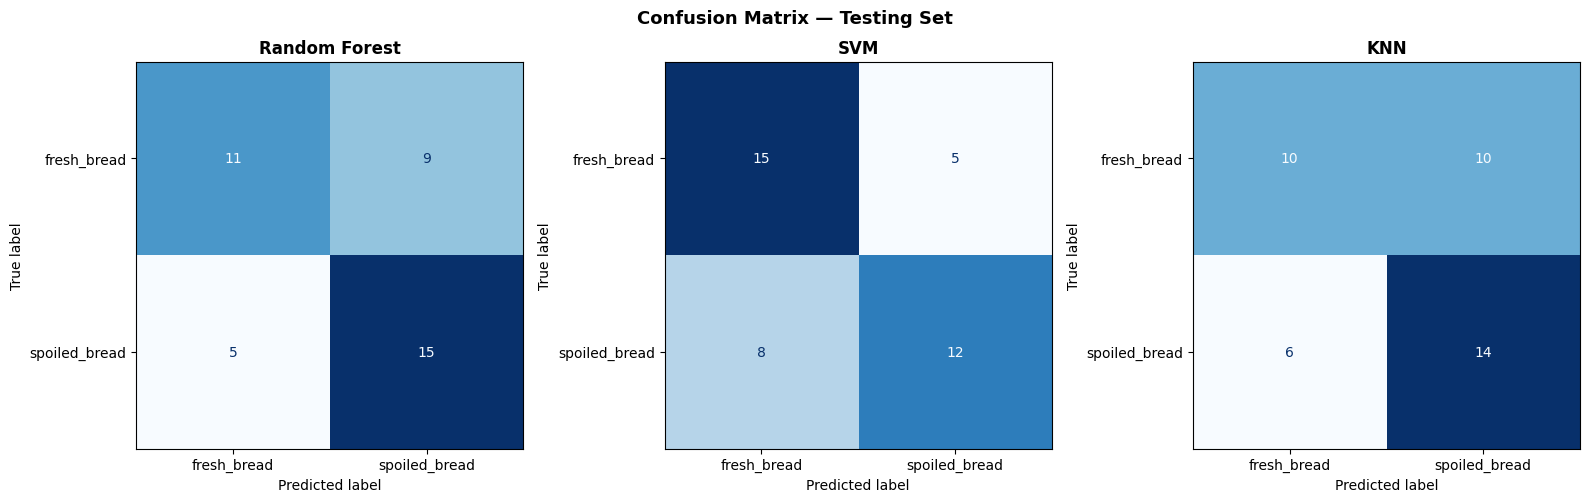


=== Ringkasan Perbandingan Model ===
               Accuracy  Precision  Recall  F1-Score
Model                                               
Random Forest     0.650     0.6562   0.650    0.6465
SVM               0.675     0.6790   0.675    0.6732
KNN               0.600     0.6042   0.600    0.5960


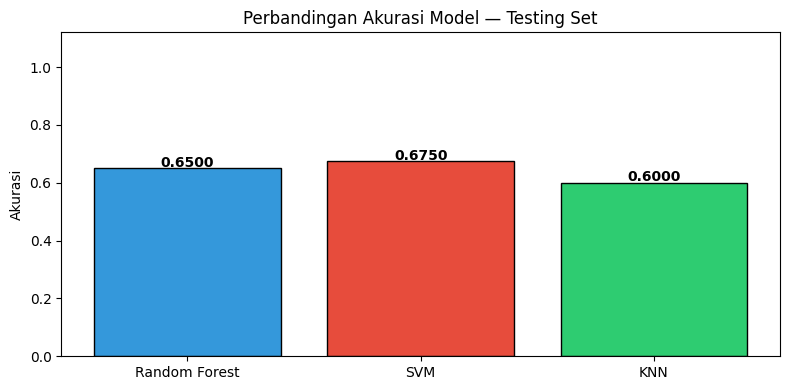

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, model, name in zip(axes, [rf, svm, knn], ['Random Forest', 'SVM', 'KNN']):
    y_pred = model.predict(X_test_norm)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=np.unique(y_test)).plot(
        cmap=plt.cm.Blues, ax=ax, colorbar=False)
    ax.set_title(name, fontweight='bold')
plt.suptitle('Confusion Matrix — Testing Set', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

rows = []
for model, name in zip([rf, svm, knn], ['Random Forest','SVM','KNN']):
    yp = model.predict(X_test_norm)
    rows.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, yp), 4),
        'Precision': round(precision_score(y_test, yp, average='weighted'), 4),
        'Recall'   : round(recall_score(y_test, yp, average='weighted'), 4),
        'F1-Score' : round(f1_score(y_test, yp, average='weighted'), 4),
    })
df_res = pd.DataFrame(rows).set_index('Model')
print("\n=== Ringkasan Perbandingan Model ===")
print(df_res.to_string())

plt.figure(figsize=(8,4))
bars = plt.bar(df_res.index, df_res['Accuracy'],
               color=['#3498db','#e74c3c','#2ecc71'], edgecolor='black')
for b, v in zip(bars, df_res['Accuracy']):
    plt.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
             f'{v:.4f}', ha='center', fontweight='bold')
plt.ylim(0, 1.12)
plt.title('Perbandingan Akurasi Model — Testing Set')
plt.ylabel('Akurasi'); plt.tight_layout(); plt.show()